In [17]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.colors as mpcolor
import matplotlib.cm as cm
from matplotlib.lines import Line2D
import math
%matplotlib inline


     #treatment      Unnamed: 1                        Unnamed: 2  \
0         db_id  participant_id                        categories   
1         15757       MGHCC0001  Hormone/Endocrine Therapy, Other   
2         15758       MGHCC0001         Hormone/Endocrine Therapy   
3         15759       MGHCC0001                      Chemotherapy   
4         15760       MGHCC0001                      Chemotherapy   
...         ...             ...                               ...   
1684      17456          MGH085                      Chemotherapy   
1685      17457          MGH085                      Chemotherapy   
1686      17458          MGH085                      Chemotherapy   
1687      17459          MGH085        Precision/Targeted Therapy   
1688      17460          MGH085        Precision/Targeted Therapy   

          Unnamed: 3                  Unnamed: 4         Unnamed: 5  \
0     drug_treatment                       drugs  drug_combinations   
1               TRUE  Letrozo

In [ ]:
import palettable
balance_6 = palettable.cmocean.diverging.Balance_6.mpl_colors
safe_10 = palettable.cartocolors.qualitative.Safe_10.mpl_colors

prism_10 = palettable.cartocolors.qualitative.Prism_10.mpl_colors

vivid_10 = palettable.cartocolors.qualitative.Vivid_10.mpl_colors
purp_7 = palettable.cartocolors.sequential.Purp_7.mpl_colormap

set1_9 = palettable.colorbrewer.qualitative.Set1_9.mpl_colormap

In [100]:
def treatment_process_centered(filename):

    df = pd.read_csv(filename, sep=',')
    print(df)
    patient_val = df['participant_id'].tolist()
    treatment_val = df['categories'].tolist()
    tx_start = df['start_date_dfd'].tolist()
    tx_end = df['stop_date_dfd'].tolist()
    stop_reason=df['stop_reason'].tolist()
    
    new_dict = {'patient': patient_val,
               'treatment': treatment_val,
               'tx_start': tx_start,
               'tx_end': tx_end,
               'stop':stop_reason}
    
    return new_dict

def generate_patientYpos(patient_DF):
    """
    Return a dictionary with unique patients as keys, and 
    y positions as values, for plotting. Assumes the column with 
    the patient names is called "patient"
    """
    
    patient_ids=list(patient_DF['patient'])
    y_pos={}
    new_pos=0
    
    for patient_name in patient_ids:
        if patient_name not in y_pos:
            new_pos=new_pos+0.25
            y_pos[patient_name]=new_pos
    
    return y_pos

In [102]:
treats=pd.DataFrame(treatment_process_centered('Juric_Rapid_Autopsy_MASTER-treatments1.csv'))
treats=treats.head(400) #just for ease while coding

#ra= treats[treats['patient'].str.contains('RA')]
#mgh= treats[treats['patient'].str.contains('mgh')]


      db_id participant_id                        categories  drug_treatment  \
0     15757      MGHCC0001  Hormone/Endocrine Therapy, Other            True   
1     15758      MGHCC0001         Hormone/Endocrine Therapy            True   
2     15759      MGHCC0001                      Chemotherapy            True   
3     15760      MGHCC0001                      Chemotherapy            True   
4     15761      MGHCC0001        Precision/Targeted Therapy            True   
...     ...            ...                               ...             ...   
1683  17456         MGH085                      Chemotherapy            True   
1684  17457         MGH085                      Chemotherapy            True   
1685  17458         MGH085                      Chemotherapy            True   
1686  17459         MGH085        Precision/Targeted Therapy            True   
1687  17460         MGH085        Precision/Targeted Therapy            True   

                           drugs drug_c

In [103]:
#mghpatient_pos=generate_patientYpos(mgh)
#rapatient_pos=generate_patientYpos(ra)
patient_pos=generate_patientYpos(treats)
treatment = treats['treatment'].unique()
patients = treats['patient'].unique()

cmap = plt.cm.viridis 
colors = [cmap(i) for i in np.linspace(0, 1, len(treatment))]
colorpal=dict(zip(treatment,colors))
print(colorpal)

treat_len = len(treatment)

{'Hormone/Endocrine Therapy, Other': (0.267004, 0.004874, 0.329415, 1.0), 'Hormone/Endocrine Therapy': (0.283229, 0.120777, 0.440584, 1.0), 'Chemotherapy': (0.267968, 0.223549, 0.512008, 1.0), 'Precision/Targeted Therapy': (0.229739, 0.322361, 0.545706, 1.0), nan: (0.190631, 0.407061, 0.556089, 1.0), 'Chemotherapy, Precision/Targeted Therapy': (0.157729, 0.485932, 0.558013, 1.0), 'Hormone/Endocrine Therapy, Precision/Targeted Therapy': (0.127568, 0.566949, 0.550556, 1.0), 'Biological Therapy, Chemotherapy': (0.126326, 0.644107, 0.525311, 1.0), 'Biological Therapy, Chemotherapy, Precision/Targeted Therapy': (0.20803, 0.718701, 0.472873, 1.0), 'Other': (0.369214, 0.788888, 0.382914, 1.0), 'Biological Therapy': (0.565498, 0.84243, 0.262877, 1.0), 'Immunotherapy': (0.783315, 0.879285, 0.125405, 1.0), 'Biological Therapy, Precision/Targeted Therapy': (0.993248, 0.906157, 0.143936, 1.0)}


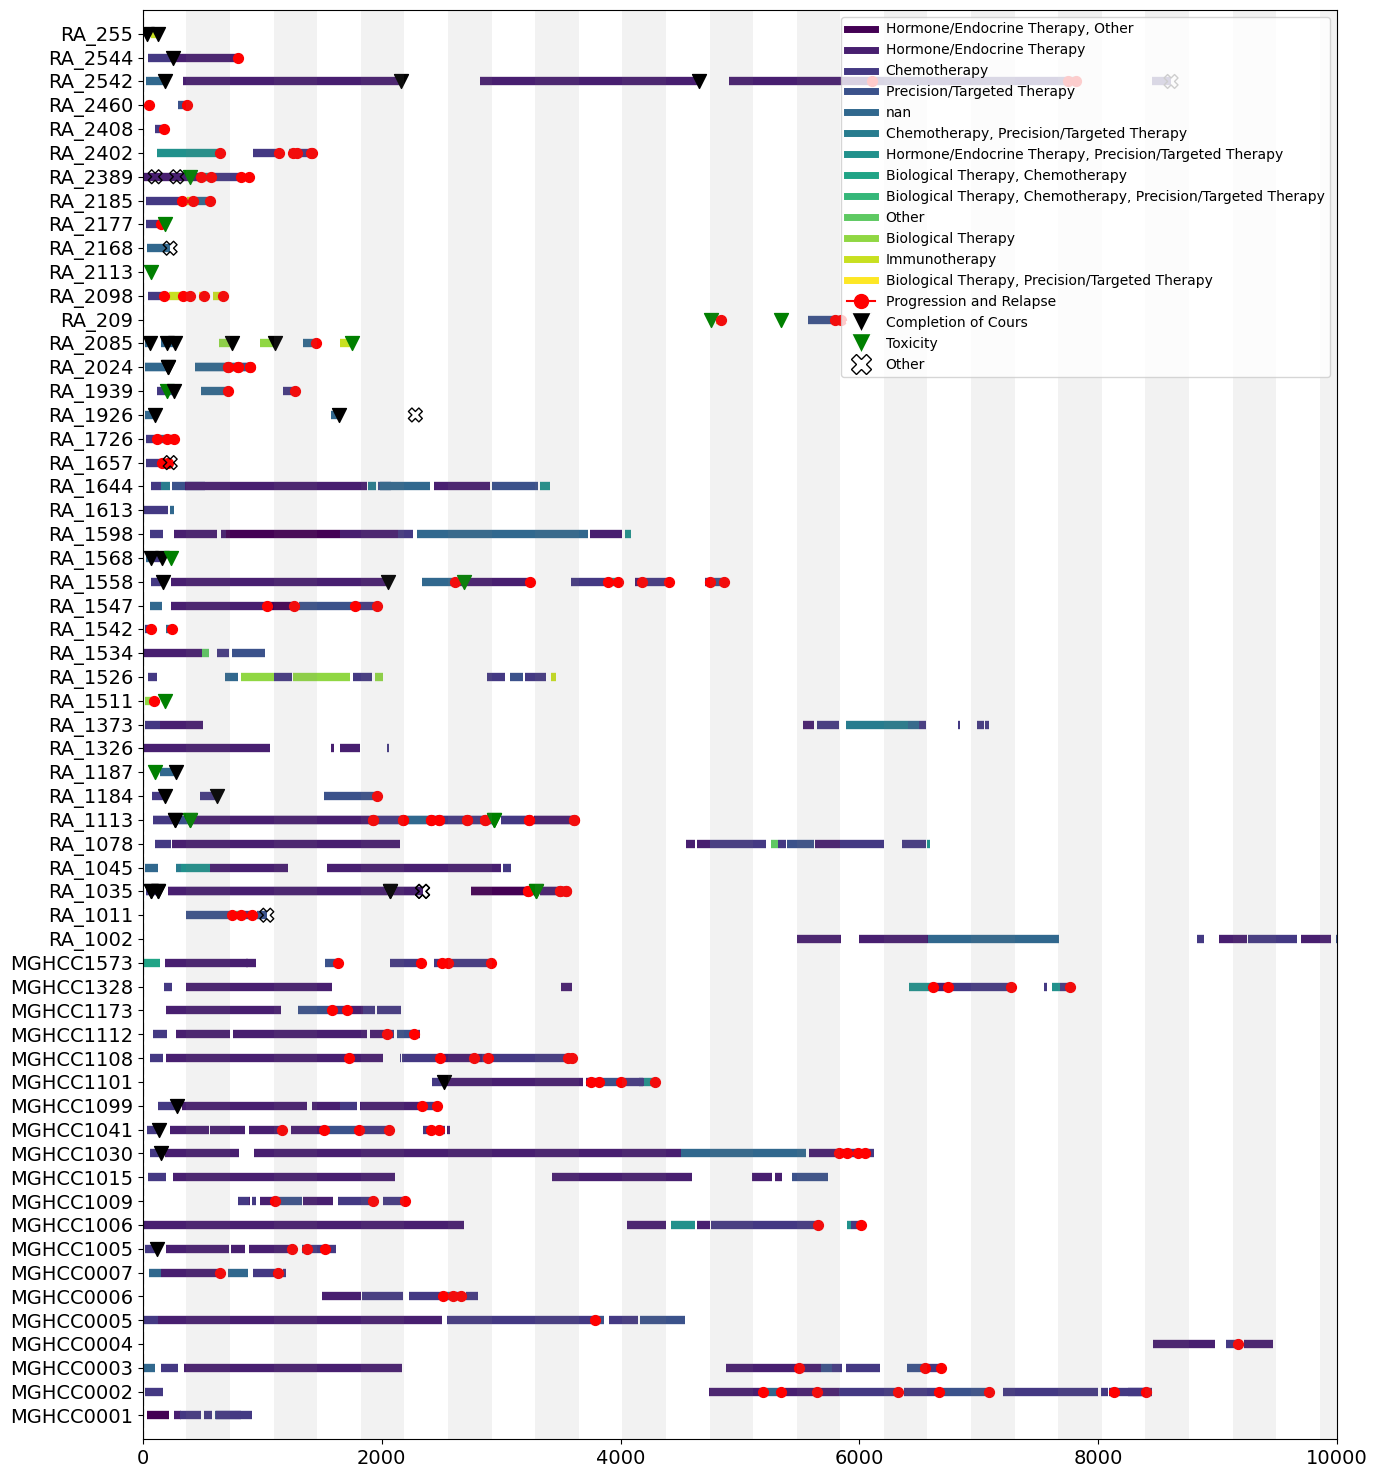

In [111]:
plt.rcParams.update({'font.size': 14})
plt.rcParams['svg.fonttype'] = 'none'
plt.figure(figsize=(14,15))

#f=plt.subplot(5,5,1)
ax=plt.gca()

bottom_length=0
top_length=15

for idx, row in treats.iterrows():
    y_pos=patient_pos[row["patient"]]
    #y_pos=1.0
    ax.hlines(y_pos, 
              float(row['tx_start']), 
              float(row['tx_end']), 
              color=colorpal[row['treatment']],
              linewidths=6, 
              zorder=-1, 
              label=str(row['treatment']))
    
for idx, row in treats.iterrows():
    y_pos=patient_pos[row["patient"]]
    if row['stop'] == 'Progression and relapse':
        ax.scatter(float(row['tx_end']), y_pos, marker='.', c='r', s=200, zorder=1, label=row['stop'])
    if row['stop'] == 'Completion of standard course':
        ax.scatter(float(row['tx_end']), y_pos, marker='v', c='k', s=100, zorder=1, label=row['stop'])
    if row['stop'] == 'Toxicity':
        ax.scatter(float(row['tx_end']), y_pos, marker='v', c='#008000', s=100, zorder=1, label=row['stop'])
    if row['stop'] == 'Other':
        ax.scatter(float(row['tx_end']), y_pos, marker='X', edgecolors='k', s=100, facecolors='none', zorder=1, label=row['stop'])

#shading for each year
counter=-1
n=365
for i in range(0, 10000, n):
    counter=counter+1

    #Ignore every other chromosome for the patches
    if counter%2==0:continue

    newpatch=mpatches.Rectangle([i, bottom_length], n, top_length-bottom_length, ec="none",color='gray', alpha=0.1)
    ax.add_patch(newpatch)

ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['left'].set_visible(True)    

ax.set_xlim(0, 10000)
ax.set_ylim(bottom_length, top_length)
ax.set_yticks(list(patient_pos.values()))
ax.set_yticklabels(list(patient_pos.keys()))

ax.vlines(0, bottom_length, top_length, color='black', linestyles='--')

legend_elements=[]

#Add the treatments
for farmac in colorpal:
    new_legend=Line2D([0], [0], color=colorpal[farmac], lw=5, label=farmac)
    legend_elements.append(new_legend)


#Add the stop dots
legend_elements.append(Line2D([0], [0], marker='.', color='r', label= 'Progression and Relapse', markerfacecolor='r', markersize=20))
legend_elements.append(Line2D([0], [0], marker='v', color='w', label='Completion of Cours', markerfacecolor='k', markersize=15))
legend_elements.append(Line2D([0], [0], marker='v', color='w', label='Toxicity', markerfacecolor='#008000', markersize=15))
legend_elements.append(Line2D([0], [0], marker='X', color='w', label='Other', markerfacecolor='none',markeredgecolor='k', markersize=15))


ax.legend(handles=legend_elements, loc=1, borderaxespad=0.5,fontsize=10)
plt.tight_layout()